In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 서울시 상권분석서비스(점포-상권)_2024년.zip to 서울시 상권분석서비스(점포-상권)_2024년.zip
Saving 서울시 상권분석서비스(영역-상권).zip to 서울시 상권분석서비스(영역-상권).zip
Saving LONG_FOREIGNER_GU_2024.zip to LONG_FOREIGNER_GU_2024.zip
Saving TEMP_FOREIGNER_GU_2024.zip to TEMP_FOREIGNER_GU_2024.zip
Saving LOCAL_PEOPLE_GU_2024.zip to LOCAL_PEOPLE_GU_2024.zip


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving adm_grid_mapping.xls to adm_grid_mapping.xls


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving adm_code.xls to adm_code.xls


In [ ]:
import pandas as pd
import geopandas as gpd
import zipfile
import io

# 1. 상권 점포수 데이터 ZIP 읽기
shop_zip = '서울시 상권분석서비스(점포-상권)_2024년.zip'
with zipfile.ZipFile(shop_zip, 'r') as z:
    csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    with z.open(csv_name) as f:
        market_raw = pd.read_csv(f, encoding='cp949')

# 2. 상권 영역(위치) ZIP 읽기
market_geo = gpd.read_file('zip://서울시 상권분석서비스(영역-상권).zip')

# --- [강력한 컬럼명 매칭 로직] ---

# Print columns to identify correct join keys
print("Columns in market_raw:", market_raw.columns)
print("Columns in market_geo:", market_geo.columns)

# Assuming '상권_코드' for raw data and 'TRDAR_CD' for geo data based on common patterns and previous errors.
# Please verify these column names from the print output above.
raw_code_col = '상권_코드'
geo_code_col = 'TRDAR_CD' # Often 'TRDAR_CD' is used in spatial data for commercial district code

print(f"매칭된 CSV 컬럼: {raw_code_col}")
print(f"매칭된 SHP 컬럼: {geo_code_col}")

# 컬럼명 통일
market_raw = market_raw.rename(columns={raw_code_col: 'join_code'})
market_geo = market_geo.rename(columns={geo_code_col: 'join_code'})

# --- [전처리 및 병합] ---

# [Step 1] 데이터 타입 일치 (문자열로 통일하여 매칭율 상승)
market_raw['join_code'] = market_raw['join_code'].astype(str)
market_geo['join_code'] = market_geo['join_code'].astype(str)

# [Step 2] 병합 (위치 데이터에 점포 데이터 붙이기)
market_combined = market_geo.merge(market_raw, on='join_code')

# [Step 3] 쓰레기 유발 업종 필터링
# 캡처화면의 '서비스_업종_코드_명' 컬럼 활용
target_col = '서비스_업종_코드_명'
target_sectors = ['커피-음료', '편의점', '패스트푸드점', '제과점']

# 데이터 내에 공백이 있을 수 있으므로 제거 후 필터링
market_combined[target_col] = market_combined[target_col].str.strip()
market_filtered = market_combined[market_combined[target_col].isin(target_sectors)].copy()

# [Step 4] 상권별 중심점(Centroid) 구하기
# The 'geometry' column in market_filtered now holds the polygons,
# we want to derive center_point from it for later use.
# This will overwrite the geometry with the centroids if not careful.
# Let's create a new column for centroid.
market_filtered['center_point'] = market_filtered.geometry.centroid

# 위도(latitude)와 경도(longitude) 추출
market_filtered['latitude'] = market_filtered['center_point'].y
market_filtered['longitude'] = market_filtered['center_point'].x

print("\n✅ 병합 성공!")
print(f"최종 결과 행 개수: {len(market_filtered)}")
print(market_filtered[['상권_코드_명', target_col, '점포_수', 'latitude', 'longitude']].head())

Columns in market_raw: Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드',
       '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률',
       '폐업_점포_수', '프랜차이즈_점포_수'],
      dtype='object')
Columns in market_geo: Index(['TRDAR_SE_C', 'TRDAR_SE_1', 'TRDAR_CD', 'TRDAR_CD_N', 'XCNTS_VALU',
       'YDNTS_VALU', 'SIGNGU_CD', 'SIGNGU_CD_', 'ADSTRD_CD', 'ADSTRD_CD_',
       'RELM_AR', 'geometry'],
      dtype='object')
매칭된 CSV 컬럼: 상권_코드
매칭된 SHP 컬럼: TRDAR_CD

✅ 병합 성공!
최종 결과 행 개수: 20428
            상권_코드_명 서비스_업종_코드_명  점포_수       latitude      longitude
3   배화여자대학교(박노수미술관)         제과점     8  453417.959549  197093.208258
4   배화여자대학교(박노수미술관)      패스트푸드점     5  453417.959549  197093.208258
8   배화여자대학교(박노수미술관)       커피-음료    49  453417.959549  197093.208258
31  배화여자대학교(박노수미술관)         편의점     0  453417.959549  197093.208258
60  배화여자대학교(박노수미술관)         제과점     8  453417.959549  197093.208258


In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pulp import *
from scipy.spatial.distance import cdist
import zipfile

# 1. 자치구별 생활인구 데이터 통합 (가중치 산정용)
def load_csv_from_zip(zip_path, encoding='cp949'): # Add encoding parameter with default
    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_name) as f:
            return pd.read_csv(f, encoding=encoding) # Use the parameter

local_pop = load_csv_from_zip('LOCAL_PEOPLE_GU_2024.zip')
# Rename columns in local_pop for consistency with other dataframes
local_pop = local_pop.rename(columns={'adstrd_code_se': '자치구코드', 'tot_lvpop_co': '총생활인구수'})
long_foreign = load_csv_from_zip('LONG_FOREIGNER_GU_2024.zip')
temp_foreign = load_csv_from_zip('TEMP_FOREIGNER_GU_2024.zip', encoding='utf-8') # Specify utf-8 for this file

# 자치구별 평균 인구 산출 및 가중치 합산 (단기 체류 외국인에 가중치 1.5배)
pop_merged = local_pop.groupby('자치구코드')['총생활인구수'].mean().to_frame('local')
pop_merged['long_f'] = long_foreign.groupby('자치구코드')['총생활인구수'].mean()
pop_merged['temp_f'] = temp_foreign.groupby('자치구코드')['총생활인구수'].mean()
pop_merged['total_weight'] = pop_merged['local'] + pop_merged['long_f'] + (pop_merged['temp_f'] * 1.5)

# 2. 상권 좌표 데이터에 자치구 가중치 매핑
# 이전 단계에서 성공한 market_filtered를 사용합니다.
# Convert SIGNGU_CD to numeric type before merge to avoid ValueError
market_filtered['SIGNGU_CD'] = pd.to_numeric(market_filtered['SIGNGU_CD'], errors='coerce')
# 자치구별 인구를 해당 구에 속한 상권 점포 수 비율로 배분합니다.
market_filtered = market_filtered.merge(pop_merged.reset_index(), left_on='SIGNGU_CD', right_on='자치구코드', how='left')
# 지점별 가중치 = (구 전체 인구 가중치 * 해당 지점 점포 수 / 구 전체 점포 수)
market_filtered['final_w'] = market_filtered['total_weight'] * (market_filtered['점포_수'] / market_filtered.groupby('SIGNGU_CD')['점포_수'].transform('sum'))

# 3. MCLP 모델 정의
def solve_mclp(df, K, Radius):
    """
    K: 설치할 쓰레기통 개수
    Radius: 커버 반경 (단위: 위경도 거리, 약 0.001이 100m 수준)
    """
    coords = df[['latitude', 'longitude']].values
    weights = df['final_w'].values
    num_nodes = len(df)

    # 거리 행렬 계산
    dist_matrix = cdist(coords, coords, 'euclidean')
    mask = (dist_matrix <= Radius).astype(int)

    # 최적화 문제 정의
    prob = LpProblem("Waste_Bin_Optimization", LpMaximize)

    # 결정 변수
    x = LpVariable.dicts("x", range(num_nodes), cat='Binary') # 설치 여부
    y = LpVariable.dicts("y", range(num_nodes), cat='Binary') # 커버 여부

    # 목적 함수: 커버되는 가중치 합 최대화
    prob += lpSum([weights[i] * y[i] for i in range(num_nodes)])

    # 제약 조건
    prob += lpSum([x[j] for j in range(num_nodes)]) == K # K개 설치
    for i in range(num_nodes):
        prob += lpSum([mask[i][j] * x[j] for j in range(num_nodes)]) >= y[i]

    # 해결
    prob.solve(PULP_CBC_CMD(msg=0))

    selected_indices = [j for j in range(num_nodes) if value(x[j]) == 1]
    return df.iloc[selected_indices]

# 4. 실행 (예: 서울시 전체 중 50곳 선정, 반경 100m 커버)
# 데이터가 너무 많으면 특정 구를 필터링해서 돌리는 것을 추천합니다.
target_gu = market_filtered[market_filtered['SIGNGU_CD_'] == '송파구'] # 예시: 송파구 집중 분석
final_locations = solve_mclp(target_gu, K=20, Radius=0.001)

print(f"✅ 최적 입지 {len(final_locations)}개 선정 완료!")
print(final_locations[['상권_코드_명', 'latitude', 'longitude', 'final_w']])

✅ 최적 입지 20개 선정 완료!
              상권_코드_명       latitude      longitude       final_w
18629         잠실 관광특구  446334.081295  210187.711747  12109.006909
18675           새마을시장  445500.178508  207534.313636   1500.230945
18759         방이동먹자골목  446106.316413  209657.054484    214.318706
18812             오금역  444708.593036  211153.574832    214.318706
18842           경찰병원역  444031.646112  210867.641859    428.637413
18856      장지역(가든파이브)  442073.650665  210906.198668    321.478060
18871             문정역  442902.928102  210607.596143   2143.187064
18887           가락시장역  443922.352634  210498.621428    321.478060
18918           몽촌토성역  446282.346996  210030.492044    321.478060
18940       석촌역(석촌호수)  445177.649361  209419.857972    750.115472
18961             잠실역  446061.314395  208953.474860   9537.182433
18973           석촌고분역  444876.756350  208581.376749   1821.709004
18986       잠실새내역(신천)  445671.082391  207301.116029    642.956119
19081          석촌역 3번  445180.258713  209894.618564    53

/tmp/ipykernel_3681/898969503.py:45: UserWarning: Glyph 51104 (\N{HANGUL SYLLABLE JAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/898969503.py:45: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/898969503.py:45: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/898969503.py:45: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/898969503.py:45: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/898969503.py:45: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/898969503.py:45: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

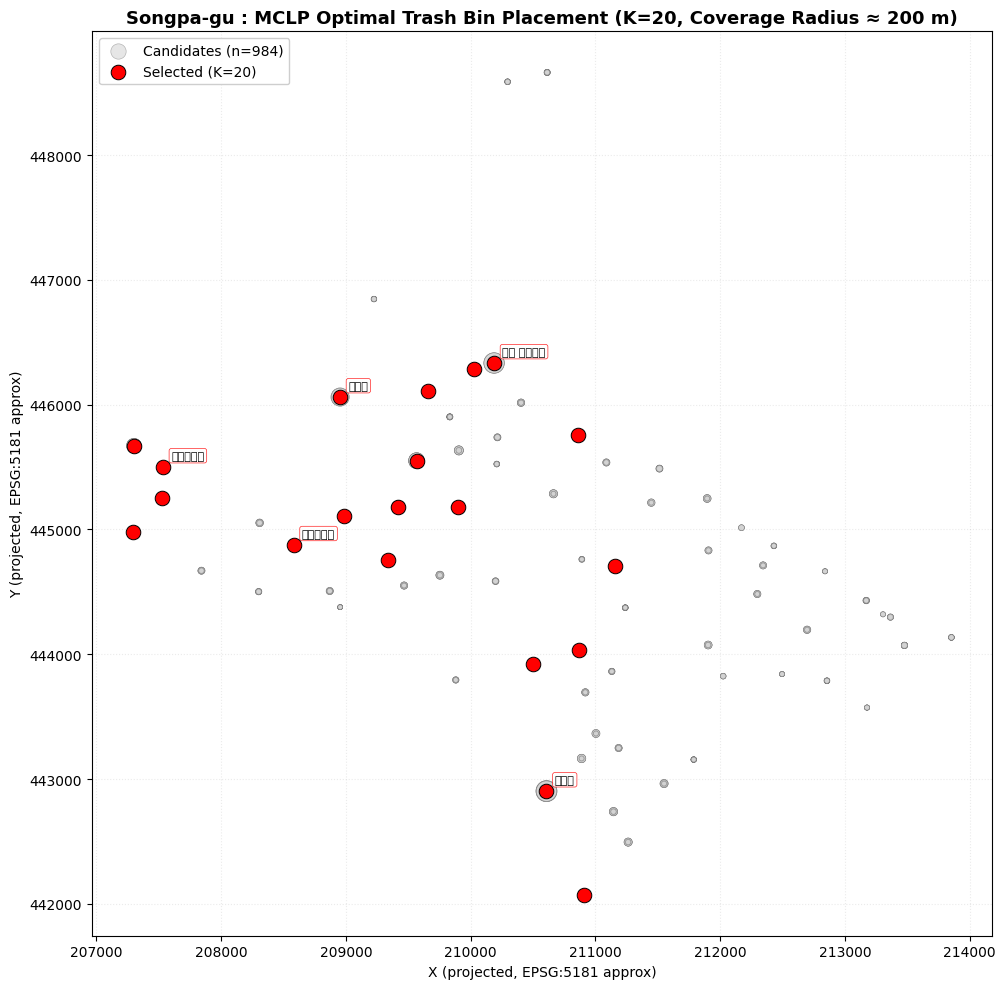

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

selset = set(final_locations.index)
cand = target_gu.loc[~target_gu.index.isin(selset)]
sel  = final_locations

fig, ax = plt.subplots(figsize=(11, 10))

# Candidates: grey, size = weight
sz = (cand['final_w'] / cand['final_w'].max() * 220 + 12) if len(cand) else 12
ax.scatter(cand['longitude'], cand['latitude'],
           s=sz, c='lightgrey', edgecolor='dimgrey',
           alpha=0.55, linewidth=0.4, label=f'Candidates (n={len(cand)})')

# 200 m coverage rings (R=0.002 in projected ~ ≈200 m)
R = 0.002
for _, r in sel.iterrows():
    ax.add_patch(Circle((r['longitude'], r['latitude']), R,
                        facecolor='red', edgecolor='red',
                        alpha=0.10, linewidth=0.6))

# Selected 20
ax.scatter(sel['longitude'], sel['latitude'],
           s=110, c='red', edgecolor='black', linewidth=0.7,
           zorder=5, label=f'Selected (K={len(sel)})')

# Top-5 weight labels
for _, r in sel.nlargest(5, 'final_w').iterrows():
    ax.annotate(r['상권_코드_명'],
                xy=(r['longitude'], r['latitude']),
                xytext=(6, 6), textcoords='offset points',
                fontsize=8, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white',
                          ec='red', alpha=0.85, lw=0.5))

ax.set_xlabel('X (projected, EPSG:5181 approx)')
ax.set_ylabel('Y (projected, EPSG:5181 approx)')
ax.set_title('Songpa-gu : MCLP Optimal Trash Bin Placement '
             '(K=20, Coverage Radius ≈ 200 m)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.95)
ax.set_aspect('equal')
ax.grid(True, alpha=0.25, linestyle=':')
plt.tight_layout()
plt.show()

In [ ]:
import folium
import geopandas as gpd
from shapely.geometry import Point

# Build a GeoDataFrame of centroids with assumed CRS = EPSG:5181 (Seoul commercial data),
# then reproject to WGS84 for folium.
gdf = gpd.GeoDataFrame(
    target_gu.copy(),
    geometry=[Point(xy) for xy in zip(target_gu['longitude'], target_gu['latitude'])],
    crs='EPSG:5181'
).to_crs(epsg=4326)
gdf['lon_wgs'] = gdf.geometry.x
gdf['lat_wgs'] = gdf.geometry.y

selset = set(final_locations.index)
gdf_sel = gdf.loc[gdf.index.isin(selset)]
gdf_cand = gdf.loc[~gdf.index.isin(selset)]

m = folium.Map(location=[gdf['lat_wgs'].mean(), gdf['lon_wgs'].mean()],
               zoom_start=13, tiles='CartoDB positron')

# Candidates
for _, r in gdf_cand.iterrows():
    folium.CircleMarker(
        location=[r['lat_wgs'], r['lon_wgs']],
        radius=3, color='#888', weight=1,
        fill=True, fill_opacity=0.45,
        popup=f"Candidate<br>{r['상권_코드_명']}<br>w={r['final_w']:.0f}"
    ).add_to(m)

# Selected with 200 m coverage
for _, r in gdf_sel.iterrows():
    folium.Circle(
        location=[r['lat_wgs'], r['lon_wgs']],
        radius=200, color='#d62728', weight=1,
        fill=True, fill_opacity=0.10
    ).add_to(m)
    folium.CircleMarker(
        location=[r['lat_wgs'], r['lon_wgs']],
        radius=7, color='#d62728', weight=2,
        fill=True, fill_opacity=0.9,
        popup=f"<b>SELECTED</b><br>{r['상권_코드_명']}<br>w={r['final_w']:.0f}"
    ).add_to(m)

legend = '''
<div style="position: fixed; top: 12px; right: 12px; z-index:9999;
     background:white; padding:10px 12px; border:2px solid #333;
     font-family:sans-serif; font-size:12px;">
  <b>Songpa-gu MCLP (K=20, R=200m)</b><br>
  <span style="color:#d62728;font-size:16px;">●</span> Selected<br>
  <span style="color:#888;font-size:16px;">●</span> Candidate
</div>'''
m.get_root().html.add_child(folium.Element(legend))
m